In [ ]:
import numpy as np
import pickle
import os

# Load data
with open('/content/drive/MyDrive/data-Physionet/train_dataset.pkl', 'rb') as f:
    d = pickle.load(f)
    X_train, y_train = d['X_train'], d['y_train']

with open('/content/drive/MyDrive/data-Physionet/test_dataset.pkl', 'rb') as f:
    d = pickle.load(f)
    X_test, y_test = d['X_test'], d['y_test']

# Labels
labels = {'Normal': 0, 'Hemorhage': 1}
# Create a reverse mapping for printing
idx_to_label = {value: key for key, value in labels.items()}

# Split data training / validation

from sklearn.model_selection import train_test_split

# 2. Take 25% of the remaining training pool for Validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribuição de classes no conjunto de treino:")
unique, counts = np.unique(y_train, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

print("\nDistribuição de classes no conjunto de validação:")
unique, counts = np.unique(y_val, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

print("\nDistribuição de classes no conjunto de teste:")
unique, counts = np.unique(y_test, return_counts=True)
for i in range(len(unique)):
    print(f"{idx_to_label[unique[i]]}: {counts[i]}")

X_train shape: (1684, 256, 256)
y_train shape: (1684,)
X_test shape: (568, 256, 256)
y_test shape: (568,)

Distribuição de classes no conjunto de treino:
Normal: 1499
Hemorhage: 185

Distribuição de classes no conjunto de validação:
Normal: 500
Hemorhage: 62

Distribuição de classes no conjunto de teste:
Normal: 497
Hemorhage: 71


In [ ]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------------------------------------
# Configuração
# -----------------------------------------------------------------------------------------
IMG_SIZE      = (256, 256)
INPUT_SHAPE   = (*IMG_SIZE, 1)     # (256, 256, 1)
PATCH_SIZE    = 8                 # 256/8 = 32 -> 32x32 = 1024 patches
NUM_PATCHES   = (IMG_SIZE[0] // PATCH_SIZE) * (IMG_SIZE[1] // PATCH_SIZE)

# Reduzidos em relação ao original (128/8) para combater overfitting.
# Se o dataset crescer ou o overfitting diminuir, pode voltar a subir.
NUM_FEATURES  = 96
EXPANSION     = 4
NUM_LAYERS    = 6
DROPOUT       = 0.2                # subiu de 0.1 -> 0.2
HEAD_DROPOUT  = 0.3

# Stochastic Depth: taxa cresce linearmente por camada (0 -> MAX_DROP_PATH)
MAX_DROP_PATH = 0.2

LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
BATCH_SIZE    = 16
EPOCHS        = 100
WARMUP_EPOCHS = 5
LABEL_SMOOTHING = 0.05

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# -----------------------------------------------------------------------------------------
# Data Augmentation (aplicado apenas no treino)
# -----------------------------------------------------------------------------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name="data_augmentation")


# -----------------------------------------------------------------------------------------
# Stochastic Depth (DropPath)
# -----------------------------------------------------------------------------------------
class StochasticDepth(layers.Layer):
    """Descarta o caminho residual inteiro com prob. drop_prob durante o treino."""
    def __init__(self, drop_prob, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        random_tensor = tf.floor(random_tensor)
        return (x / keep_prob) * random_tensor

    def get_config(self):
        config = super().get_config()
        config.update({"drop_prob": self.drop_prob})
        return config


# -----------------------------------------------------------------------------------------
# Definição do modelo - MLP-Mixer
# -----------------------------------------------------------------------------------------
def mlp_block(x, hidden_dim, out_dim, dropout_rate):
    """MLP de 2 camadas com GELU e Dropout (equivalente ao MLP do paper)."""
    x = layers.Dense(hidden_dim, activation='gelu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(out_dim)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def token_mixer(x, num_patches, expansion, dropout_rate, drop_path_rate):
    """
    Mistura informação ENTRE PATCHES.
    Entrada/saída: (B, num_patches, num_features)
    """
    residual = x
    x = layers.LayerNormalization()(x)
    x = layers.Permute((2, 1))(x)                          # (B, C, P)
    x = mlp_block(x, num_patches * expansion, num_patches, dropout_rate)
    x = layers.Permute((2, 1))(x)                          # (B, P, C)
    x = StochasticDepth(drop_path_rate)(x)
    return layers.Add()([x, residual])


def channel_mixer(x, num_features, expansion, dropout_rate, drop_path_rate):
    """
    Mistura informação ENTRE CANAIS (por patch).
    Entrada/saída: (B, num_patches, num_features)
    """
    residual = x
    x = layers.LayerNormalization()(x)
    x = mlp_block(x, num_features * expansion, num_features, dropout_rate)
    x = StochasticDepth(drop_path_rate)(x)
    return layers.Add()([x, residual])


def mixer_layer(x, num_patches, num_features, expansion, dropout_rate, drop_path_rate):
    x = token_mixer(x, num_patches, expansion, dropout_rate, drop_path_rate)
    x = channel_mixer(x, num_features, expansion, dropout_rate, drop_path_rate)
    return x


def build_mlp_mixer(input_shape=(256, 256, 1),
                    patch_size=16,
                    num_features=96,
                    expansion=4,
                    num_layers=6,
                    dropout=0.2,
                    head_dropout=0.3,
                    max_drop_path=0.2,
                    use_augmentation=True):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs) if use_augmentation else inputs

    # Patch embedding: Conv2D com kernel = stride = patch_size
    x = layers.Conv2D(
        filters=num_features,
        kernel_size=patch_size,
        strides=patch_size,
        padding='valid',
        name='patch_embedding'
    )(x)                                                    # (B, H', W', C)

    Hp = input_shape[0] // patch_size
    Wp = input_shape[1] // patch_size
    num_patches = Hp * Wp

    # (B, H', W', C) -> (B, P, C)
    x = layers.Reshape((num_patches, num_features))(x)

    # N camadas de Mixer, com drop-path crescente linearmente (regra de Huang et al.)
    for i in range(num_layers):
        drop_path_rate = max_drop_path * i / max(1, num_layers - 1)
        x = mixer_layer(x, num_patches, num_features, expansion, dropout, drop_path_rate)

    # Pooling global sobre patches + cabeça de classificação binária
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)                 # (B, num_features)
    x = layers.Dropout(head_dropout)(x)
    x = layers.Dense(1, activation='sigmoid', name='classifier')(x)

    return keras.Model(inputs, x, name='MLP_Mixer')


model = build_mlp_mixer(
    input_shape=INPUT_SHAPE,
    patch_size=PATCH_SIZE,
    num_features=NUM_FEATURES,
    expansion=EXPANSION,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    head_dropout=HEAD_DROPOUT,
    max_drop_path=MAX_DROP_PATH,
    use_augmentation=True,
)

model.summary()

# -----------------------------------------------------------------------------------------
# Learning rate schedule: warmup linear + cosine decay
# -----------------------------------------------------------------------------------------
# steps_per_epoch precisa ser definido a partir do seu dataset real, ex:
#   steps_per_epoch = len(train_dataset)  # se for tf.data.Dataset já batelado
#   ou steps_per_epoch = X_train.shape[0] // BATCH_SIZE
steps_per_epoch = X_train.shape[0] // BATCH_SIZE          # ajuste conforme seu pipeline
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = WARMUP_EPOCHS * steps_per_epoch

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=total_steps - warmup_steps,
    warmup_target=LEARNING_RATE,
    warmup_steps=warmup_steps,
)

# -----------------------------------------------------------------------------------------
# Compilação
# -----------------------------------------------------------------------------------------
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

# -----------------------------------------------------------------------------------------
# Callbacks
# -----------------------------------------------------------------------------------------
# ReduceLROnPlateau foi removido porque o schedule (cosine decay) já controla o LR;
# usar os dois juntos costuma brigar entre si.
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=12,
                  restore_best_weights=True),
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print("Class weights:", class_weight_dict)

Model: "MLP_Mixer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 32, 32,    │      6,240 │ data_augmentatio… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1024, 96)  │          0 │ patch_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1024, 96)  │        192 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 96, 1024)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96, 4096)  │  4,198,400 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96, 4096)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96, 1024)  │  4,195,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96, 1024)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 1024, 96)  │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_depth    │ (None, 1024, 96)  │          0 │ permute_1[0][0]   │
│ (StochasticDepth)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 96)  │          0 │ stochastic_depth… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 96)  │        192 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024, 384) │     37,248 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024, 384) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024, 96)  │     36,960 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1024, 96)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_depth_1  │ (None, 1024, 96)  │          0 │ dropout_3[0][0]   │
│ (StochasticDepth)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 96)  │          0 │ stochastic_depth… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 50,816,449 (193.85 MB)

 Trainable params: 50,816,449 (193.85 MB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 0.561707805203469, 1: 4.551351351351351}


In [ ]:
import time

# -----------------------------------------------------------------------------------------
# Treinamento
# -----------------------------------------------------------------------------------------
start_time = time.time()

history = model.fit(
    X_train, y_train,
    shuffle=True,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("\nTraining completed.\n")
print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} min")

Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 63s 347ms/step - accuracy: 0.6532 - auc: 0.7247 - loss: 0.6133 - precision: 0.1963 - recall: 0.6973 - val_accuracy: 0.6157 - val_auc: 0.7835 - val_loss: 0.6045 - val_precision: 0.2016 - val_recall: 0.8387
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 344ms/step - accuracy: 0.6704 - auc: 0.7840 - loss: 0.5698 - precision: 0.2247 - recall: 0.8162 - val_accuracy: 0.6246 - val_auc: 0.7977 - val_loss: 0.6433 - val_precision: 0.2101 - val_recall: 0.8710
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 37s 352ms/step - accuracy: 0.6657 - auc: 0.7851 - loss: 0.5639 - precision: 0.2221 - recall: 0.8162 - val_accuracy: 0.6584 - val_auc: 0.8026 - val_loss: 0.5894 - val_precision: 0.2198 - val_recall: 0.8226
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 358ms/step - accuracy: 0.6799 - auc: 0.8014 - loss: 0.5448 - precision: 0.2226 - recall: 0.7676 - val_accuracy: 0.6210 - val_auc: 0.8213 - val_loss: 0.6357 - val_precision: 0.2107 - val_recall: 0.8871
Epoch 5/100
106/

In [ ]:
# Evaluate the model on the test set
print("Evaluating on test set...")
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Test Precision: {test_precision:.3f}")
print(f"Test Recall: {test_recall:.3f}")
print(f"Test AUC: {test_auc:.3f}")

Evaluating on test set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.8239 - auc: 0.8534 - loss: 0.3997 - precision: 0.3739 - recall: 0.6056

Test Loss: 0.400
Test Accuracy: 0.824
Test Precision: 0.374
Test Recall: 0.606
Test AUC: 0.853


In [ ]:
# Classification report
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = y_test

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(labels.keys())))

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.86      0.89       497
   Hemorhage       0.37      0.61      0.46        71

    accuracy                           0.82       568
   macro avg       0.66      0.73      0.68       568
weighted avg       0.87      0.82      0.84       568



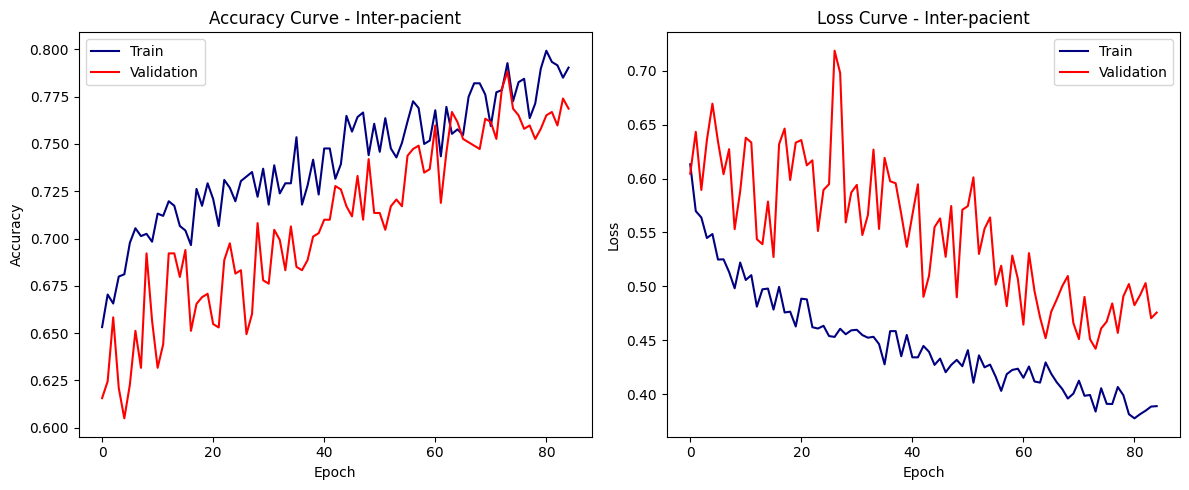

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='navy')
plt.plot(history.history['val_accuracy'], color='red')
plt.title('Accuracy Curve - Inter-pacient')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='navy')
plt.plot(history.history['val_loss'], color='red')
plt.title('Loss Curve - Inter-pacient')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

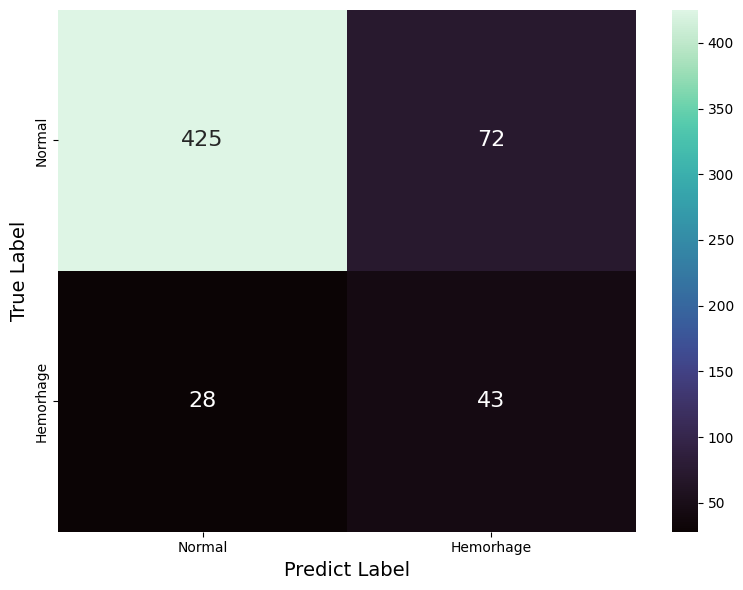

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve

y_pred_classes = (y_pred > 0.5).astype(int).flatten()

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_classes)

# Plotar
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=True,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 16})
# plt.xticks(rotation=45)
plt.xlabel('Predict Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

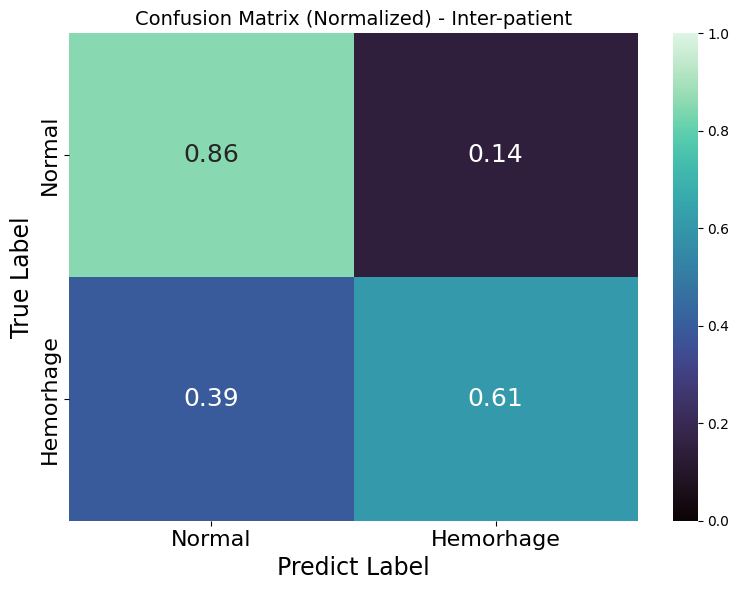

In [ ]:
# Matriz de porcentagens -- NORMALIZAÇÃO POR LINHA (SENSIBILIDADE E ESPECIFICIDADE NA DIAGONAL PRINCIPAL)
plt.figure(figsize=(8, 6))
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# Normalização por COLUNA (mostra precision)
# cm_percent_col = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]

sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='mako', cbar=True,  # .2% mostra como %
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 18}, vmin=0, vmax=1)  # Escala fixa 0-100%
# plt.xticks(rotation=45)
plt.xlabel('Predict Label', fontsize=17)
plt.ylabel('True Label', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Confusion Matrix (Normalized) - Inter-patient', fontsize=14)
plt.tight_layout()
plt.show()

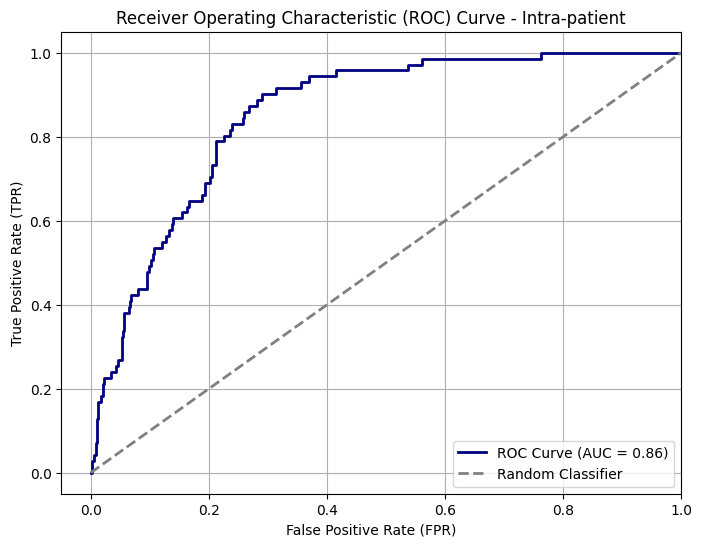

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='navy', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve - Inter-patient')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()